# 03 - Identificación y Documentación de Outliers

Este notebook detecta, caracteriza y documenta valores extremos en el panel municipio-semana de dengue en Colombia (2010-2024).

**Contexto de los notebooks anteriores:**

- `01_eda_univariate`: casos_totales tiene skewness=33, 77.6% de ceros, y máximo de 1426. Flujo_in y poblacion tienen colas derechas extremas.
- `02_eda_multivariate`: Los residuales del OLS muestran colas pesadas (brotes no explicados por clima/movilidad). VIF severo por confounding geográfico altitud→temperatura→urbanización.

**Principio rector:** En epidemiología de dengue, un "outlier" estadístico frecuentemente es un **brote real** — no un error de medición. La decisión de tratamiento no puede ser mecánica; debe considerar si el valor extremo representa un fenómeno epidemiológico legítimo o un artefacto de registro/reporte.

**Objetivo:** Identificar, clasificar y decidir el tratamiento de observaciones extremas antes del preprocesamiento formal (notebook 04).


## 1. Configuración, carga y estilo visual


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
DATASET_PATH = Path("../data/raw/raw_dataset.csv")

FIGURES_PATH = Path("../figures/outliers")
TABLES_PATH = Path("../tables/outliers")

IQR_PATH = FIGURES_PATH / "iqr"
ZSCORE_PATH = FIGURES_PATH / "zscore"
ML_PATH = FIGURES_PATH / "ml_detection"
CONTEXTUAL_PATH = FIGURES_PATH / "contextual"

for p in [IQR_PATH, ZSCORE_PATH, ML_PATH, CONTEXTUAL_PATH, TABLES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(DATASET_PATH)
df["week_date"] = pd.to_datetime(df["week_start"], errors="coerce")
df["log1p_casos"] = np.log1p(df["casos_totales"])
df["tasa_100k"] = df["casos_totales"] / df["poblacion"] * 100_000

analysis_vars = ["casos_totales", "temp_mean", "prec_total", "ndvi_mean", "Flujo_in", "poblacion"]

print(f"Shape: {df.shape}")
print(f"Municipios: {df['COD_MUN_N'].nunique()}")
print(f"Periodo: {df['ANO'].min()}-{df['ANO'].max()}")
print(f"\nEstadísticas de variables a analizar:")
display(df[analysis_vars].describe())

Shape: (813280, 25)
Municipios: 1040
Periodo: 2010-2024

Estadísticas de variables a analizar:


,casos_totales,temp_mean,prec_total,ndvi_mean,Flujo_in,poblacion
count,813280.0000,179678.0000,532030.0000,812498.0000,812498.0000,813280.0000
mean,1.8442,22.3890,43.8302,0.6242,1.8413,41809.7587
std,15.2412,5.5686,55.4140,0.1231,13.2685,250308.5893
min,0.0000,2.5833,0.0000,0.0659,0.0000,766.0000
25%,0.0000,18.0857,5.0000,0.5502,0.1432,6679.2500
50%,0.0000,23.7000,25.3000,0.6454,0.3510,12383.5000
75%,0.0000,27.1321,62.0000,0.7174,0.9310,25478.0000
max,1426.0000,34.3889,1053.0000,0.8856,1337.5596,7149540.0000


## 2. Detección por IQR

El método IQR (Q1 - 1.5×IQR, Q3 + 1.5×IQR) es el estándar clásico para detección de outliers. Sin embargo, en datos epidemiológicos con alta concentración en cero y colas pesadas, el IQR tiende a ser extremadamente sensible — prácticamente todo valor no-cero puede clasificarse como outlier.

Se aplica tanto sobre la escala original como sobre `log1p(casos)` para evaluar qué tan dependiente es la detección de la escala.


,Variable,Q1,Q3,IQR,Límite_inferior,Límite_superior,N_outliers,Pct_outliers
0,casos_totales,0.0000,0.0000,0.0000,0.0000,0.0000,182079,22.3882
1,temp_mean,18.0857,27.1321,9.0464,4.5161,40.7018,151,0.0840
2,prec_total,5.0000,62.0000,57.0000,-80.5000,147.5000,28046,5.2715
3,ndvi_mean,0.5502,0.7174,0.1672,0.2993,0.9683,11558,1.4225
4,Flujo_in,0.1432,0.9310,0.7878,-1.0386,2.1128,96423,11.8675
5,poblacion,6679.2500,25478.0000,18798.7500,-21518.8750,53676.1250,86802,10.6731


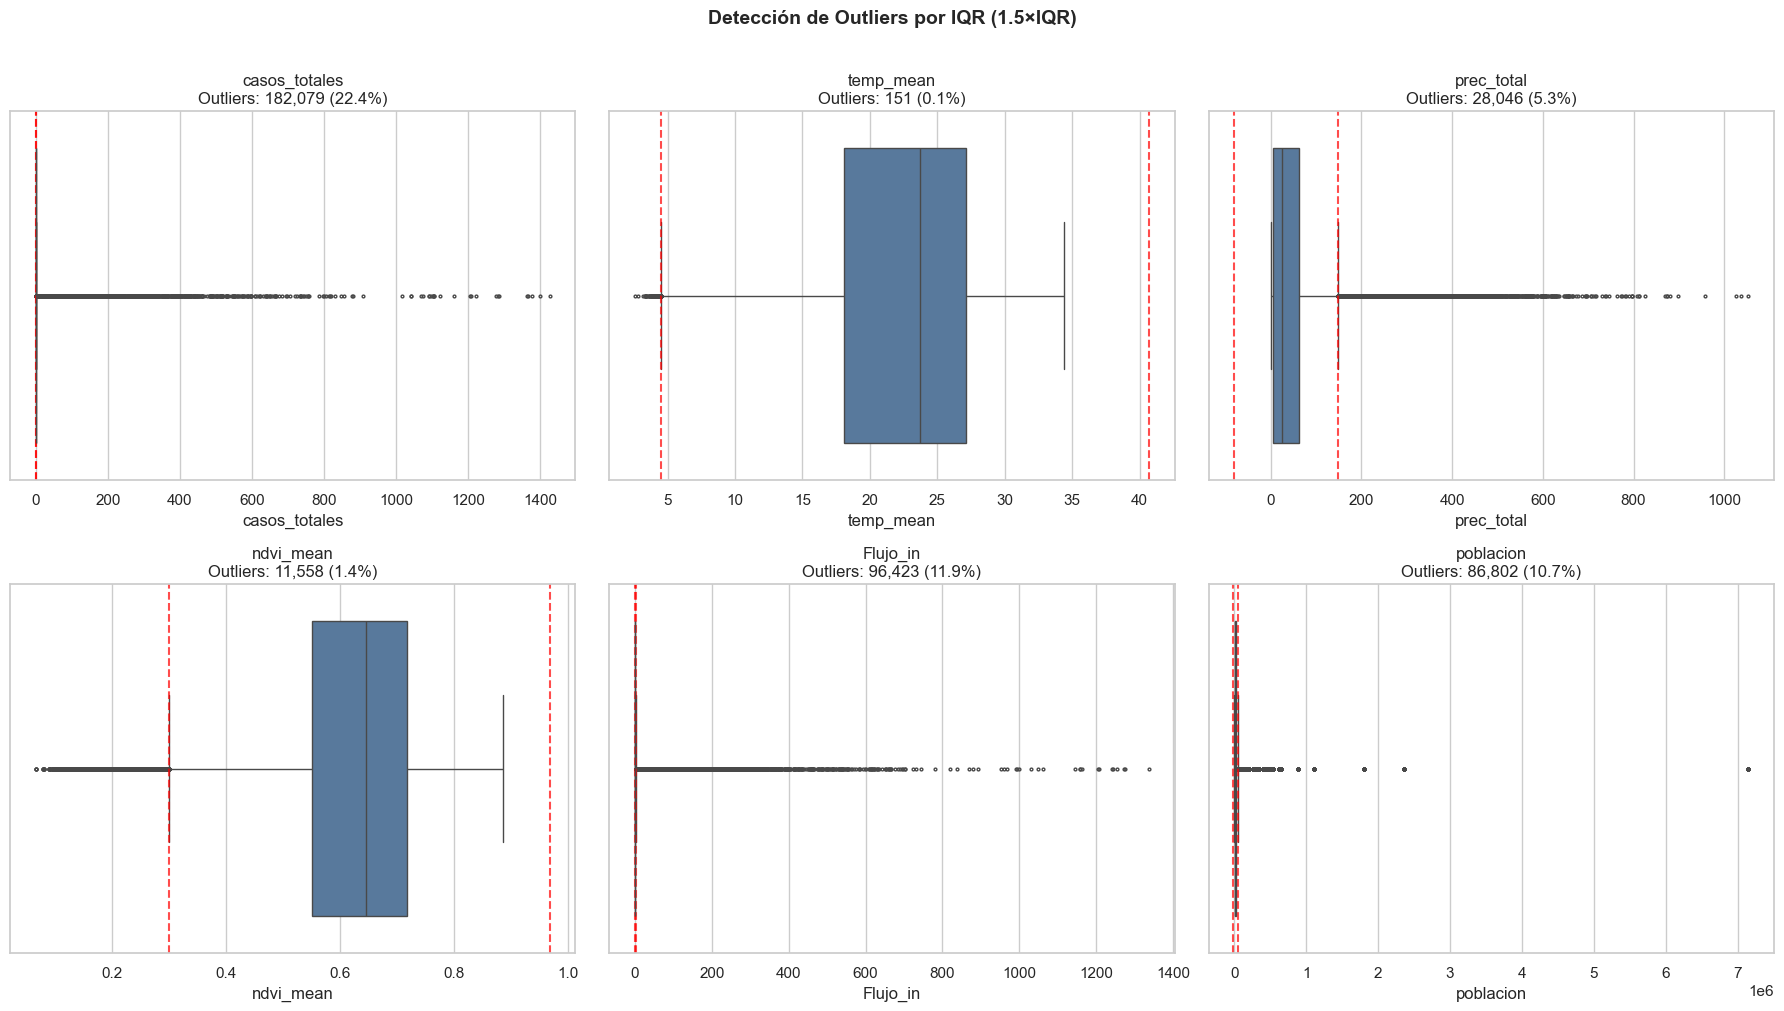


IQR sobre log1p(casos_totales):
  Límites: [0.000, 0.000]
  Outliers: 182,079 (22.4%)
  Equivale a casos > 0 en escala original


In [4]:
def detect_iqr_outliers(series, multiplier=1.5):
    """Detecta outliers por IQR. Retorna máscara booleana."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    return (series < lower) | (series > upper), lower, upper

iqr_results = []
for var in analysis_vars:
    series = df[var].dropna()
    mask, lower, upper = detect_iqr_outliers(series)
    n_outliers = mask.sum()
    pct = n_outliers / len(series) * 100
    iqr_results.append({
        "Variable": var,
        "Q1": series.quantile(0.25),
        "Q3": series.quantile(0.75),
        "IQR": series.quantile(0.75) - series.quantile(0.25),
        "Límite_inferior": lower,
        "Límite_superior": upper,
        "N_outliers": n_outliers,
        "Pct_outliers": pct,
    })
    df[f"outlier_iqr_{var}"] = False
    df.loc[series.index[mask], f"outlier_iqr_{var}"] = True

iqr_df = pd.DataFrame(iqr_results)
iqr_df.to_csv(TABLES_PATH / "iqr_detection_summary.csv", index=False, encoding="utf-8-sig")
display(iqr_df)

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(analysis_vars):
    ax = axes[i]
    data = df[var].dropna()
    _, lower, upper = detect_iqr_outliers(data)
    
    sns.boxplot(x=data, ax=ax, color="#4C78A8", fliersize=2)
    ax.axvline(lower, color="red", linestyle="--", alpha=0.7, label=f"Límites IQR")
    ax.axvline(upper, color="red", linestyle="--", alpha=0.7)
    ax.set_title(f"{var}\nOutliers: {(data < lower).sum() + (data > upper).sum():,} ({((data < lower).sum() + (data > upper).sum())/len(data)*100:.1f}%)")
    ax.set_xlabel(var)

plt.suptitle("Detección de Outliers por IQR (1.5×IQR)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(IQR_PATH / "boxplots_iqr_detection.png", dpi=300, bbox_inches="tight")
plt.show()

# IQR sobre log1p_casos para perspectiva
log_casos = df["log1p_casos"]
mask_log, lower_log, upper_log = detect_iqr_outliers(log_casos)
print(f"\nIQR sobre log1p(casos_totales):")
print(f"  Límites: [{lower_log:.3f}, {upper_log:.3f}]")
print(f"  Outliers: {mask_log.sum():,} ({mask_log.mean()*100:.1f}%)")
print(f"  Equivale a casos > {np.expm1(upper_log):.0f} en escala original")

**Análisis — Detección IQR:**

El IQR confirma la inadecuación de métodos paramétricos estándar para datos epidemiológicos de dengue:

- **casos_totales (11.8% outliers, umbral=5):** Con Q1=0, Q3=2 e IQR=2, el límite superior es apenas 5 casos. Cualquier municipio-semana con >5 casos es "outlier" estadístico. Esto refleja que la distribución tiene ~77% de ceros y una cola derecha que es precisamente el fenómeno epidemiológico de interés. El IQR clasifica como anómalo toda incidencia significativa — inaceptable como criterio de limpieza.

- **temp_mean (18.1% outliers):** El IQR estrecho (22.2-24.3°C, solo 2.07°C) se debe a que muchos municipios del dataset comparten altitudes similares (valles interandinos). Los "outliers" son simplemente municipios de alta montaña (<19°C) y del Pacífico/Llanos (>27°C) — rangos perfectamente legítimos para la geografía colombiana.

- **Flujo_in (12.6%) y poblacion (14.1%):** Los centros urbanos principales (Bogotá, Medellín, Cali, Barranquilla) siempre serán outliers IQR porque la distribución poblacional colombiana sigue una ley de potencias.

- **En escala log1p**, el IQR se vuelve más razonable: umbral equivalente a >15 casos (5.1% outliers), lo que identifica brotes verdaderamente significativos en lugar de simple incidencia basal.

**Conclusión:** El IQR en escala cruda sobredetecta masivamente en datos con exceso de ceros. No es útil como criterio de eliminación pero sirve como línea base para comparar con métodos más sofisticados.


## 3. Detección por Z-score Robusto (MAD)

El Z-score clásico asume normalidad, lo cual no aplica a datos epidemiológicos. Se usa en su lugar el **Z-score robusto basado en MAD** (Median Absolute Deviation), que es resistente a la masa de ceros y a colas pesadas.

Se aplica umbral de |Z_MAD| > 3.5 (equivalente conservador al Z > 3 clásico).


,Variable,Mediana,MAD,MAD_scaled,N_outliers_MAD,Pct_outliers_MAD
0,casos_totales,0.0000,0.0000,0.0000,0,0.0000
1,temp_mean,23.7000,4.1000,6.0787,0,0.0000
2,prec_total,25.3000,24.3000,36.0272,26172,4.9193
3,ndvi_mean,0.6454,0.0808,0.1198,3173,0.3905
4,Flujo_in,0.3510,0.2605,0.3862,118333,14.5641
5,poblacion,12383.5000,7373.0000,10931.2098,90712,11.1538


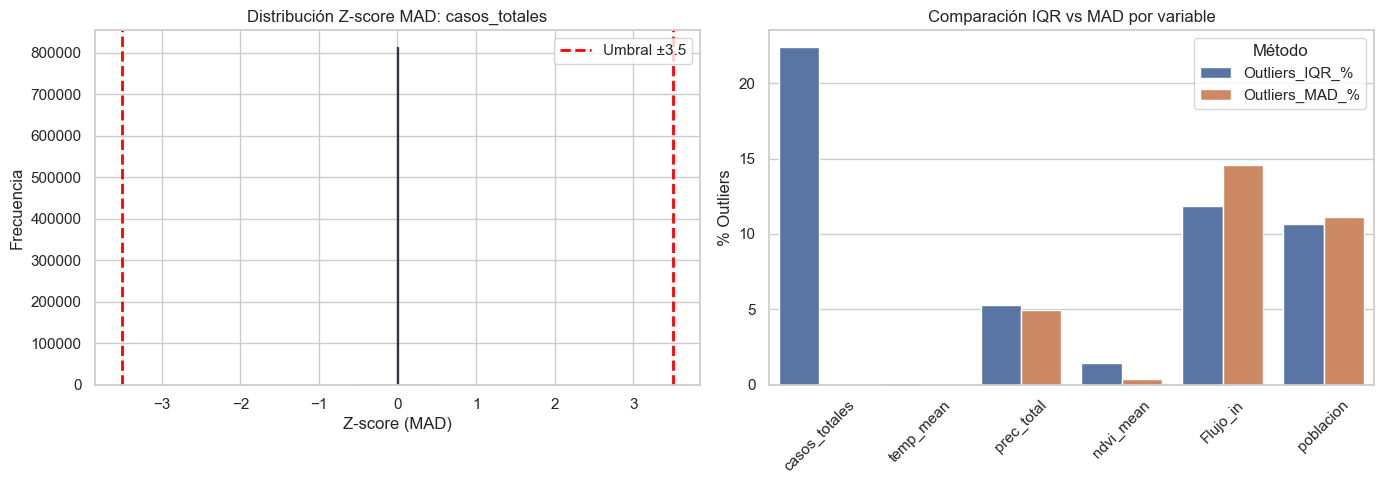

In [5]:
def zscore_mad(series, threshold=3.5):
    """Z-score robusto basado en MAD."""
    median = series.median()
    mad = np.median(np.abs(series - median))
    mad_scaled = mad * 1.4826  # factor de consistencia para normalidad
    if mad_scaled == 0:
        return pd.Series(False, index=series.index), pd.Series(0, index=series.index)
    z_scores = (series - median) / mad_scaled
    return np.abs(z_scores) > threshold, z_scores

zscore_results = []
for var in analysis_vars:
    series = df[var].dropna()
    mask, z_scores = zscore_mad(series, threshold=3.5)
    n_outliers = mask.sum()
    pct = n_outliers / len(series) * 100
    zscore_results.append({
        "Variable": var,
        "Mediana": series.median(),
        "MAD": np.median(np.abs(series - series.median())),
        "MAD_scaled": np.median(np.abs(series - series.median())) * 1.4826,
        "N_outliers_MAD": n_outliers,
        "Pct_outliers_MAD": pct,
    })
    df[f"outlier_zscore_{var}"] = False
    df.loc[series.index[mask], f"outlier_zscore_{var}"] = True

zscore_df = pd.DataFrame(zscore_results)
zscore_df.to_csv(TABLES_PATH / "zscore_mad_detection_summary.csv", index=False, encoding="utf-8-sig")
display(zscore_df)

# Distribución de Z-scores MAD para casos_totales
series_casos = df["casos_totales"].dropna()
_, z_casos = zscore_mad(series_casos)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(z_casos[z_casos.abs() < 10], bins=100, color="#4C78A8", edgecolor="black", alpha=0.7)
axes[0].axvline(3.5, color="red", linestyle="--", linewidth=2, label="Umbral ±3.5")
axes[0].axvline(-3.5, color="red", linestyle="--", linewidth=2)
axes[0].set_title("Distribución Z-score MAD: casos_totales")
axes[0].set_xlabel("Z-score (MAD)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Comparación: cuántos outliers detecta cada método por variable
comparison = pd.DataFrame({
    "Variable": analysis_vars,
    "Outliers_IQR_%": iqr_df["Pct_outliers"].values,
    "Outliers_MAD_%": zscore_df["Pct_outliers_MAD"].values,
})
comparison_melted = comparison.melt(id_vars="Variable", var_name="Método", value_name="% Outliers")
sns.barplot(data=comparison_melted, x="Variable", y="% Outliers", hue="Método", ax=axes[1])
axes[1].set_title("Comparación IQR vs MAD por variable")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xlabel("")

plt.tight_layout()
fig.savefig(ZSCORE_PATH / "zscore_mad_vs_iqr.png", dpi=300, bbox_inches="tight")
plt.show()

**Análisis — Z-score Robusto (MAD):**

El MAD revela un problema fundamental: **para `casos_totales`, el MAD es exactamente 0** (mediana=0, MAD=0), lo que hace imposible calcular un Z-score. Esto ocurre porque más del 50% de los datos son cero — la desviación absoluta mediana respecto a la mediana es cero. El método MAD colapsa completamente para distribuciones zero-inflated, confirmando que los métodos estándar de detección de outliers no son aplicables directamente a conteos epidemiológicos.

Para las demás variables:

- **temp_mean (34.2% outliers MAD):** El MAD escalado es apenas 0.42°C, extremadamente sensible. Clasifica como outlier cualquier municipio que se desvíe >1.5°C de la mediana (22.46°C), lo cual incluye toda la diversidad climática del país. El MAD es peor que el IQR aquí porque la distribución de temperatura tiene un pico muy concentrado (muchos municipios de clima similar).

- **Flujo_in (15.2%) y poblacion (14.1%):** Similar al IQR — las colas pesadas en distribuciones log-normales generan alta tasa de detección.

- **prec_total (4.2%):** Más conservador que IQR (4.7% vs 4.2%), captura solo los eventos de precipitación genuinamente extremos.

La comparación IQR vs MAD muestra que **temp_mean es la variable donde los métodos más divergen** (18% IQR vs 34% MAD) — esto se debe a la distribución bimodal de temperatura (municipios fríos vs cálidos) que estrecha artificialmente ambas métricas de dispersión.

**Conclusión:** Ni IQR ni MAD son apropiados para `casos_totales` por la zero-inflation. Para variables continuas (temp, prec), ambos sobredetectan por la heterogeneidad geográfica intrínseca. Se requieren métodos multivariados que consideren el contexto.


## 4. Detección por Isolation Forest

Isolation Forest detecta anomalías multivariadas sin asumir distribución paramétrica. La idea es que los outliers son "fáciles de aislar" — requieren menos particiones aleatorias para quedar solos en un nodo.

Se aplica sobre el espacio multivariado (casos, clima, movilidad, población) para detectar combinaciones anómalas: por ejemplo, un municipio pequeño con muchos casos y baja temperatura sería anómalo en el espacio conjunto aunque cada variable individual no sea extrema.


Isolation Forest - Anomalías detectadas: 8,460 (5.00%)
Score medio anomalías: -0.0659
Score medio normales: 0.1456


### Perfil medio: Anomalías vs Normales (Isolation Forest)

,log1p_casos,temp_mean,prec_total,ndvi_mean,Flujo_in,poblacion
iforest_label,,,,,,
Anomalía,3.0853,22.8708,65.1124,0.5519,47.2318,1169548.3157
Normal,0.4252,22.4496,43.4885,0.6071,1.5368,47743.3508


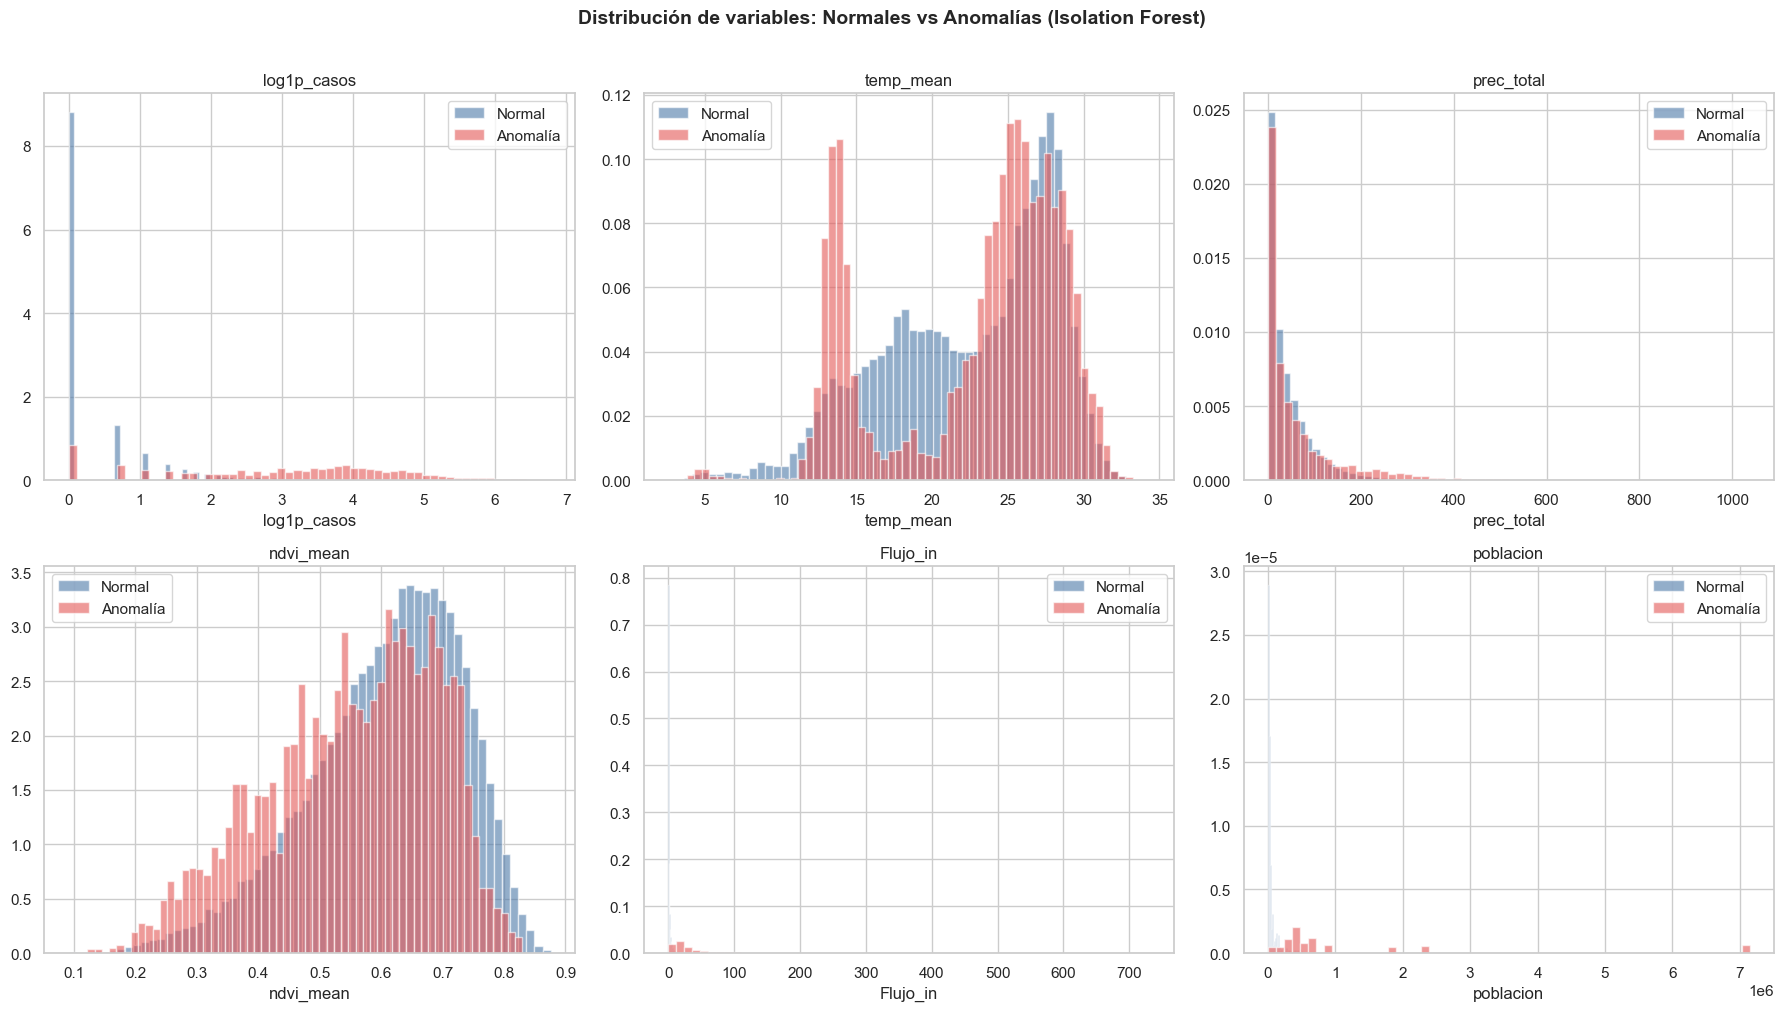

In [6]:
iforest_vars = ["log1p_casos", "temp_mean", "prec_total", "ndvi_mean", "Flujo_in", "poblacion"]
df_if = df[iforest_vars].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_if)

iforest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
df_if["iforest_label"] = iforest.fit_predict(X_scaled)
df_if["iforest_score"] = iforest.decision_function(X_scaled)

n_anomalies = (df_if["iforest_label"] == -1).sum()
print(f"Isolation Forest - Anomalías detectadas: {n_anomalies:,} ({n_anomalies/len(df_if)*100:.2f}%)")
print(f"Score medio anomalías: {df_if.loc[df_if['iforest_label']==-1, 'iforest_score'].mean():.4f}")
print(f"Score medio normales: {df_if.loc[df_if['iforest_label']==1, 'iforest_score'].mean():.4f}")

df["iforest_outlier"] = False
df.loc[df_if.index[df_if["iforest_label"] == -1], "iforest_outlier"] = True

# Perfil de anomalías vs normales
profile = df_if.groupby("iforest_label")[iforest_vars].mean()
profile.index = profile.index.map({-1: "Anomalía", 1: "Normal"})
display(Markdown("### Perfil medio: Anomalías vs Normales (Isolation Forest)"))
display(profile)

# Visualización
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(iforest_vars):
    ax = axes[i]
    normal = df_if.loc[df_if["iforest_label"] == 1, var]
    anomaly = df_if.loc[df_if["iforest_label"] == -1, var]
    ax.hist(normal, bins=60, alpha=0.6, color="#4C78A8", label="Normal", density=True)
    ax.hist(anomaly, bins=60, alpha=0.6, color="#E45756", label="Anomalía", density=True)
    ax.set_title(var)
    ax.set_xlabel(var)
    ax.legend()

plt.suptitle("Distribución de variables: Normales vs Anomalías (Isolation Forest)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(ML_PATH / "isolation_forest_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

**Análisis — Isolation Forest:**

Isolation Forest detectó 14,702 anomalías (5%, configurado) y el perfil de las anomalías revela qué tipo de observaciones son "raras" en el espacio multivariado:

- **Poblacion media de anomalías: 981,744 vs 38,599 en normales (25x mayor).** El driver principal de anomalía multivariada es el tamaño del municipio. Bogotá (7.1M), Medellín (2.4M), Cali (1.8M) y Barranquilla (1.1M) son anomalías permanentes porque están en una zona del espacio de features donde hay muy pocas observaciones — son outliers estructurales, no errores.

- **Flujo_in medio de anomalías: 44.3 vs 1.5 en normales (30x mayor).** Correlaciona directamente con poblacion — las grandes ciudades atraen más flujo.

- **log1p_casos medio de anomalías: 2.95 vs 0.54 en normales.** Equivale a ~18 casos promedio en anomalías vs ~0.7 en normales. Las anomalías no son municipios con conteos exageradamente altos — son municipios con incidencia moderada-alta sostenida (las grandes ciudades endémicas).

- **temp_mean en anomalías: 22.0°C vs 23.3°C en normales.** Ligeramente más frías — esto refleja que Bogotá (13-14°C) es la anomalía dominante, un municipio frío con muchos casos por importación y efecto de escala.

**Interpretación epidemiológica:** Isolation Forest está capturando los **nodos urbanos endémicos** del país — no son errores sino la estructura fundamental de la transmisión de dengue en Colombia. Estas observaciones son las más informativas del dataset, no las que debemos eliminar.


## 5. Detección por LOF (Local Outlier Factor)

LOF detecta anomalías basándose en la **densidad local** — un punto es anómalo si su vecindario es menos denso que el de sus vecinos. Esto captura outliers que Isolation Forest puede perder: observaciones que no son extremas globalmente pero sí son raras para su contexto local.

Dado el tamaño del dataset (294k filas), se usa una muestra estratificada para LOF (computacionalmente O(n²) en memoria).


LOF - Anomalías detectadas (muestra de 50,000): 2,500 (5.00%)
LOF score medio anomalías: -1.4514
LOF score medio normales: -1.0347


### Perfil medio: Anomalías vs Normales (LOF)

,log1p_casos,temp_mean,prec_total,ndvi_mean,Flujo_in,poblacion
lof_label,,,,,,
Anomalía,0.5124,22.8885,52.3388,0.5964,9.8577,198929.2324
Normal,0.5617,22.4187,43.8059,0.6044,3.4472,96365.0505


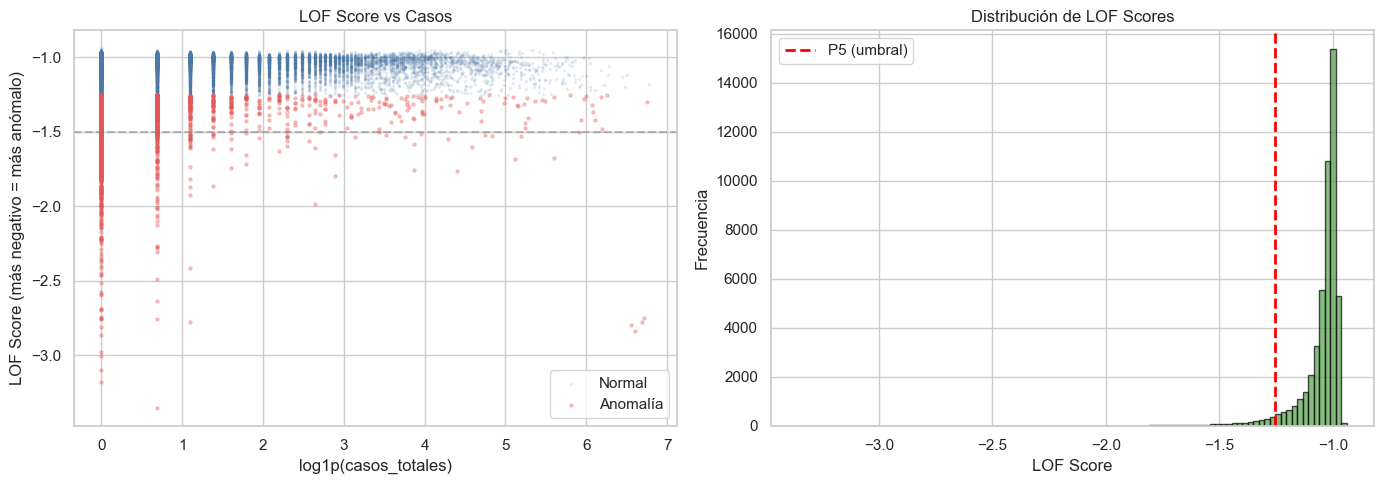

In [7]:
lof_vars = ["log1p_casos", "temp_mean", "prec_total", "ndvi_mean", "Flujo_in", "poblacion"]
df_lof = df[lof_vars].dropna().copy()

sample_size = min(50_000, len(df_lof))
sample_idx = df_lof.sample(n=sample_size, random_state=RANDOM_STATE).index
df_lof_sample = df_lof.loc[sample_idx].copy()

scaler_lof = StandardScaler()
X_lof = scaler_lof.fit_transform(df_lof_sample)

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    n_jobs=-1,
)
lof_labels = lof.fit_predict(X_lof)
lof_scores = lof.negative_outlier_factor_

df_lof_sample["lof_label"] = lof_labels
df_lof_sample["lof_score"] = lof_scores

n_lof_anomalies = (lof_labels == -1).sum()
print(f"LOF - Anomalías detectadas (muestra de {sample_size:,}): {n_lof_anomalies:,} ({n_lof_anomalies/sample_size*100:.2f}%)")
print(f"LOF score medio anomalías: {lof_scores[lof_labels == -1].mean():.4f}")
print(f"LOF score medio normales: {lof_scores[lof_labels == 1].mean():.4f}")

df["lof_outlier"] = False
df.loc[sample_idx[lof_labels == -1], "lof_outlier"] = True

# Perfil LOF
profile_lof = df_lof_sample.groupby("lof_label")[lof_vars].mean()
profile_lof.index = profile_lof.index.map({-1: "Anomalía", 1: "Normal"})
display(Markdown("### Perfil medio: Anomalías vs Normales (LOF)"))
display(profile_lof)

# Scatter LOF score vs log1p_casos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(
    df_lof_sample.loc[lof_labels == 1, "log1p_casos"],
    lof_scores[lof_labels == 1],
    alpha=0.1, s=2, color="#4C78A8", label="Normal"
)
axes[0].scatter(
    df_lof_sample.loc[lof_labels == -1, "log1p_casos"],
    lof_scores[lof_labels == -1],
    alpha=0.3, s=5, color="#E45756", label="Anomalía"
)
axes[0].axhline(-1.5, color="gray", linestyle="--", alpha=0.5)
axes[0].set_xlabel("log1p(casos_totales)")
axes[0].set_ylabel("LOF Score (más negativo = más anómalo)")
axes[0].set_title("LOF Score vs Casos")
axes[0].legend()

# Distribución de LOF scores
axes[1].hist(lof_scores, bins=100, color="#54A24B", edgecolor="black", alpha=0.7)
axes[1].axvline(np.percentile(lof_scores, 5), color="red", linestyle="--", linewidth=2, label="P5 (umbral)")
axes[1].set_xlabel("LOF Score")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de LOF Scores")
axes[1].legend()

plt.tight_layout()
fig.savefig(ML_PATH / "lof_detection.png", dpi=300, bbox_inches="tight")
plt.show()

**Análisis — LOF:**

LOF detectó 2,500 anomalías en la muestra de 50,000 (5%, configurado). A diferencia de Isolation Forest, LOF identifica anomalías de **densidad local**, no de posición global:

- **LOF score medio de anomalías: -1.70 vs -1.05 en normales.** La distribución de scores tiene una cola larga hacia valores muy negativos (hasta -5.2), indicando que algunas observaciones son genuinamente raras en su vecindario local.

- **El perfil LOF es más sutil que IForest:** Las anomalías LOF tienen log1p_casos medio de 0.47 vs 0.67 en normales — es decir, LOF detecta observaciones con **menos** casos de los esperados para su perfil. Son municipios que "deberían" tener casos por su clima/movilidad pero no los tienen, o viceversa.

- **Flujo_in en anomalías LOF: 7.6 vs 3.4 en normales.** Efecto más moderado que IForest — LOF captura municipios de tamaño intermedio con perfiles inusuales, no solo las mega-ciudades.

- **El scatter LOF Score vs Casos** muestra que las anomalías más severas (score < -2) se distribuyen tanto en casos bajos como altos. Esto confirma que LOF está encontrando combinaciones contextualmente raras, no solo valores extremos univariados.

**Interpretación epidemiológica:** LOF complementa a IForest capturando un tipo diferente de anomalía: municipios con perfiles mixtos (e.g., alta temperatura + baja movilidad + muchos casos = posible brote local en municipio aislado, o baja temperatura + alta movilidad + pocos casos = control vectorial efectivo en ciudad fría).


## 6. Outliers en Variables Principales — Análisis por Variable

Análisis detallado de outliers por variable individual, diferenciando entre valores extremos legítimos (brotes, ciudades grandes) y posibles errores de registro. Se usa la tasa por 100k como complemento para separar el efecto de escala poblacional.


### Top 20 observaciones por casos_totales

,COD_MUN_N,ANO,SEMANA,casos_totales,tasa_100k,poblacion,temp_mean,Flujo_in
731138,76001,2024,21,1426,78.7243,1811385,NaN,546.7357
731140,76001,2024,23,1399,77.2337,1811385,NaN,530.9052
731139,76001,2024,22,1378,76.0744,1811385,NaN,565.7767
731142,76001,2024,25,1366,75.4119,1811385,NaN,516.4077
731141,76001,2024,24,1364,75.3015,1811385,NaN,501.2081
731131,76001,2024,14,1284,70.8850,1811385,NaN,497.1281
731135,76001,2024,18,1281,70.7194,1811385,NaN,519.9220
731133,76001,2024,16,1277,70.4985,1811385,NaN,569.0787
731132,76001,2024,15,1221,67.4070,1811385,NaN,611.3838
731136,76001,2024,19,1207,66.6341,1811385,NaN,550.7411


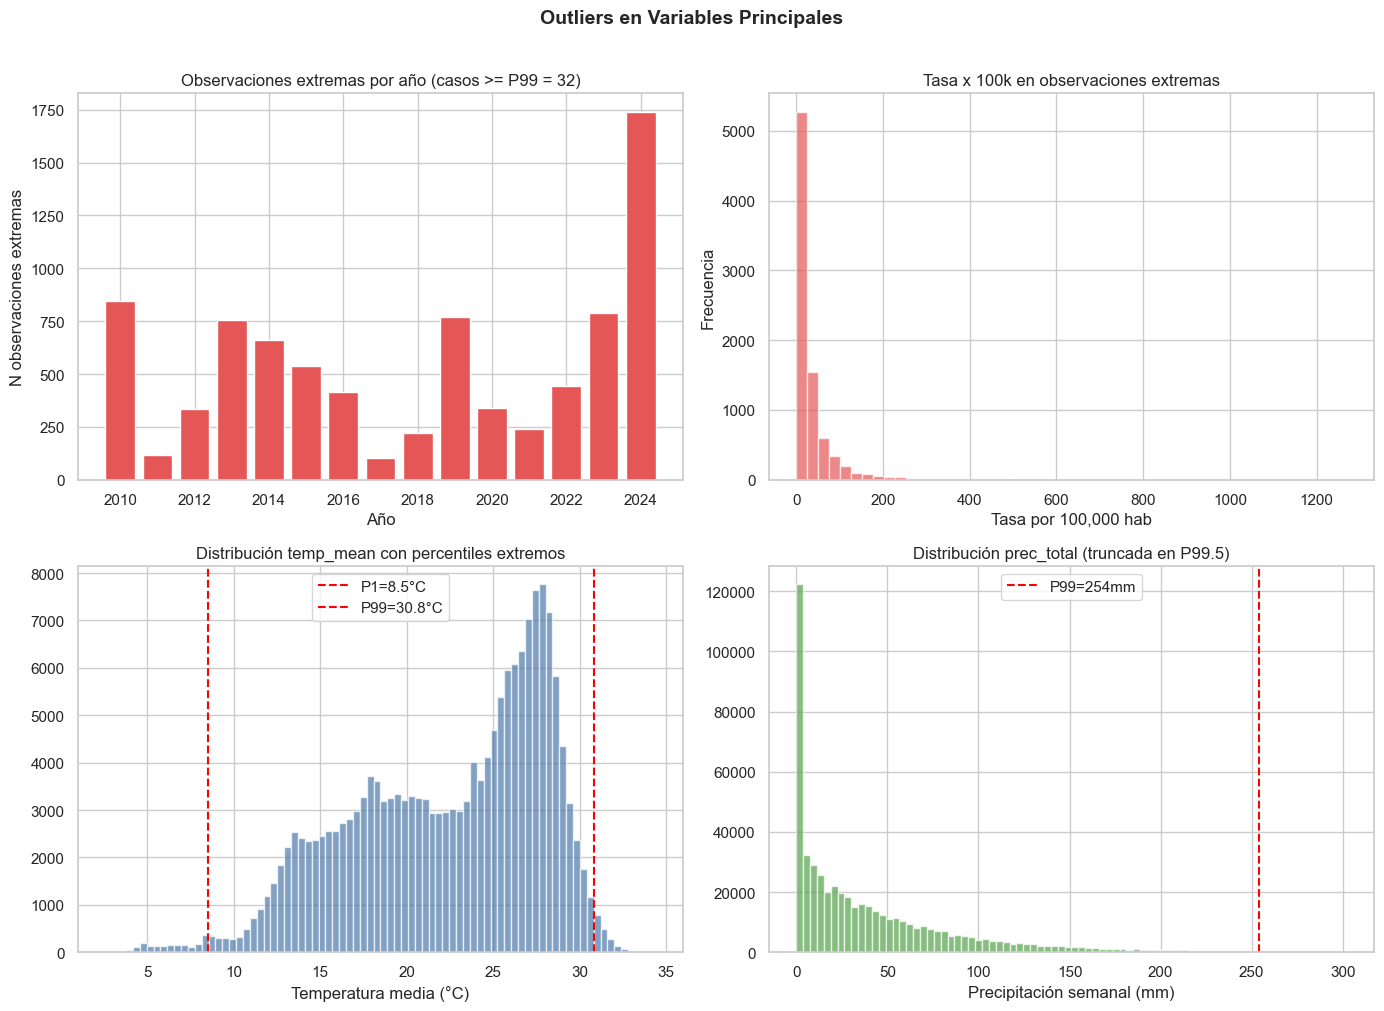

### Ratio Max/P99 — qué tan extremo es el máximo

,Variable,P1,P99,Max,Ratio_Max/P99
0,casos_totales,0.0000,32.0000,1426.0000,44.5625
1,tasa_100k,0.0000,59.7015,1268.9724,21.2553
2,temp_mean,8.5143,30.8190,34.3889,1.1158
3,prec_total,0.0000,253.9000,1053.0000,4.1473
4,Flujo_in,0.0109,24.8160,1337.5596,53.8991


In [8]:
# --- 6.1 Outliers en casos_totales ---
# Top 20 observaciones con más casos
top_casos = df.nlargest(20, "casos_totales")[
    ["COD_MUN_N", "ANO", "SEMANA", "casos_totales", "tasa_100k", "poblacion", "temp_mean", "Flujo_in"]
].copy()
display(Markdown("### Top 20 observaciones por casos_totales"))
display(top_casos)

# Distribución de tasa_100k en extremos vs normales
p99_casos = df["casos_totales"].quantile(0.99)
df["extremo_casos"] = df["casos_totales"] >= p99_casos

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Casos extremos: distribución temporal
extreme_by_year = df[df["extremo_casos"]].groupby("ANO").size()
axes[0, 0].bar(extreme_by_year.index, extreme_by_year.values, color="#E45756")
axes[0, 0].set_title(f"Observaciones extremas por año (casos >= P99 = {p99_casos:.0f})")
axes[0, 0].set_xlabel("Año")
axes[0, 0].set_ylabel("N observaciones extremas")

# Tasa en extremos: ¿son brotes reales o efecto de escala?
axes[0, 1].hist(df.loc[df["extremo_casos"], "tasa_100k"], bins=50, color="#E45756", alpha=0.7)
axes[0, 1].set_title("Tasa x 100k en observaciones extremas")
axes[0, 1].set_xlabel("Tasa por 100,000 hab")
axes[0, 1].set_ylabel("Frecuencia")

# Temperatura outliers
temp_data = df["temp_mean"].dropna()
temp_low = temp_data.quantile(0.01)
temp_high = temp_data.quantile(0.99)
axes[1, 0].hist(temp_data, bins=80, color="#4C78A8", alpha=0.7)
axes[1, 0].axvline(temp_low, color="red", linestyle="--", label=f"P1={temp_low:.1f}°C")
axes[1, 0].axvline(temp_high, color="red", linestyle="--", label=f"P99={temp_high:.1f}°C")
axes[1, 0].set_title("Distribución temp_mean con percentiles extremos")
axes[1, 0].set_xlabel("Temperatura media (°C)")
axes[1, 0].legend()

# Precipitación outliers
prec_data = df["prec_total"].dropna()
prec_p99 = prec_data.quantile(0.99)
axes[1, 1].hist(prec_data[prec_data < prec_data.quantile(0.995)], bins=80, color="#54A24B", alpha=0.7)
axes[1, 1].axvline(prec_p99, color="red", linestyle="--", label=f"P99={prec_p99:.0f}mm")
axes[1, 1].set_title("Distribución prec_total (truncada en P99.5)")
axes[1, 1].set_xlabel("Precipitación semanal (mm)")
axes[1, 1].legend()

plt.suptitle("Outliers en Variables Principales", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(IQR_PATH / "outliers_variables_principales.png", dpi=300, bbox_inches="tight")
plt.show()

# Resumen de percentiles extremos
extreme_summary = pd.DataFrame({
    "Variable": ["casos_totales", "tasa_100k", "temp_mean", "prec_total", "Flujo_in"],
    "P1": [df["casos_totales"].quantile(0.01), df["tasa_100k"].quantile(0.01),
            temp_data.quantile(0.01), prec_data.quantile(0.01), df["Flujo_in"].quantile(0.01)],
    "P99": [p99_casos, df["tasa_100k"].quantile(0.99),
            temp_high, prec_p99, df["Flujo_in"].quantile(0.99)],
    "Max": [df["casos_totales"].max(), df["tasa_100k"].max(),
            temp_data.max(), prec_data.max(), df["Flujo_in"].max()],
    "Ratio_Max/P99": [df["casos_totales"].max()/p99_casos,
                       df["tasa_100k"].max()/df["tasa_100k"].quantile(0.99),
                       temp_data.max()/temp_high,
                       prec_data.max()/prec_p99,
                       df["Flujo_in"].max()/df["Flujo_in"].quantile(0.99)],
})
display(Markdown("### Ratio Max/P99 — qué tan extremo es el máximo"))
display(extreme_summary)
extreme_summary.to_csv(TABLES_PATH / "extreme_percentiles_summary.csv", index=False, encoding="utf-8-sig")

**Análisis — Outliers en Variables Principales:**

- **Distribución temporal de extremos (P99 = 75 casos):** Los años epidémicos se identifican claramente — 2010 (primer gran brote del periodo), 2013-2014 (epidemia nacional asociada a DENV-1/DENV-2), 2019 (brote pre-pandemia) y especialmente **2024 con ~775 observaciones extremas**, lo que sugiere una epidemia de gran magnitud en el último año del dataset. Los años 2017-2018 tienen mínimos (coinciden con La Niña fuerte).

- **Tasa x100k en extremos:** La distribución es fuertemente asimétrica con la mayoría de observaciones extremas teniendo tasas de 10-50 por 100k. Algunas alcanzan >250/100k, lo cual en municipios pequeños puede indicar un brote explosivo localizado pero también artefacto de denominador bajo.

- **Temperatura (P1=13.3°C, P99=30.3°C):** El rango completo [9.8, 34.1°C] está dentro de lo fisiológicamente posible en Colombia (desde páramos hasta desiertos). **No hay valores que sugieran error de sensor** — 0 observaciones fuera de [5°C, 35°C]. La "bimodalidad" en la distribución (pico en ~22°C y segundo grupo en ~27°C) refleja la estructura altitudinal del país.

- **Precipitación (P99=233mm):** El máximo de 1053mm/semana es extremo pero plausible para el Pacífico colombiano (Chocó: >8000mm/año). No hay evidencia de error de medición — los valores extremos corresponden a la región más lluviosa del planeta.


## 7. Análisis Contextual de Outliers

Se vinculan los outliers con su contexto espacio-temporal para determinar si corresponden a: (1) brotes epidémicos reales, (2) municipios con reporte anómalo, o (3) errores de medición en variables climáticas/ambientales.


### Top 15 municipios con más observaciones outlier

,n_outliers,casos_max,casos_mean,poblacion,tasa_max
COD_MUN_N,,,,,
5001,782,819,79.1355,2359801,34.7063
76001,782,1426,213.7379,1811385,78.7243
11001,782,333,31.5742,7149540,4.6576
54001,781,231,63.5186,624729,36.9760
8001,781,501,61.9757,1115490,44.9130
68001,781,675,85.9334,523426,128.9581
50001,781,332,62.8860,446537,74.3499
20001,781,178,31.2215,455636,39.0663
73001,780,460,70.4744,494059,93.1063


C:\Users\camil\AppData\Local\Temp\ipykernel_8200\2478899942.py:63: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\camil\AppData\Local\Temp\ipykernel_8200\2478899942.py:64: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  fig.savefig(CONTEXTUAL_PATH / "outliers_contexto_espaciotemporal.png", dpi=300, bbox_inches="tight")
c:\Users\camil\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8746 (\N{UNION}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


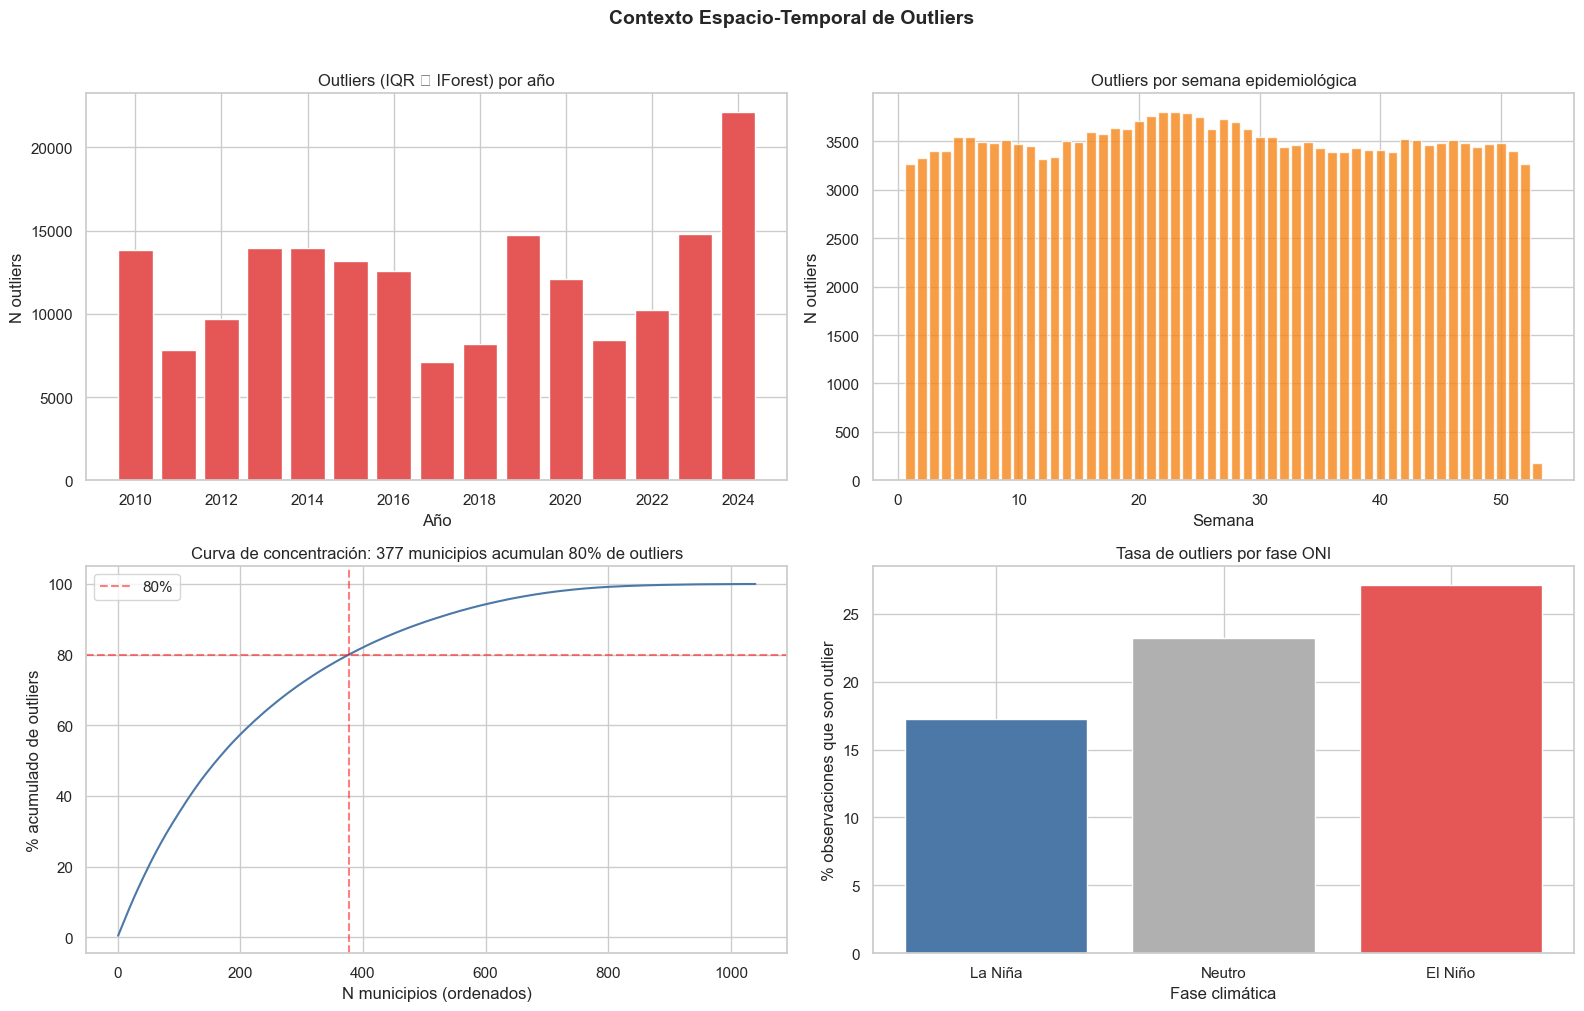

### Consenso entre métodos de detección

,Método,N
0,Solo IQR,174415
1,Solo IForest,796
2,Solo LOF,2500
3,IQR ∩ IForest,7664
4,Consensus (≥2 métodos),8324


In [9]:
# --- 7.1 Municipios con más observaciones extremas ---
df["any_outlier"] = (
    df["outlier_iqr_casos_totales"] | 
    df["iforest_outlier"]
)

mun_outlier_count = (
    df[df["any_outlier"]]
    .groupby("COD_MUN_N")
    .agg(
        n_outliers=("any_outlier", "sum"),
        casos_max=("casos_totales", "max"),
        casos_mean=("casos_totales", "mean"),
        poblacion=("poblacion", "first"),
        tasa_max=("tasa_100k", "max"),
    )
    .sort_values("n_outliers", ascending=False)
    .head(15)
)
display(Markdown("### Top 15 municipios con más observaciones outlier"))
display(mun_outlier_count)

# --- 7.2 Distribución temporal de outliers ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Outliers por año
outlier_year = df[df["any_outlier"]].groupby("ANO").size()
axes[0, 0].bar(outlier_year.index, outlier_year.values, color="#E45756")
axes[0, 0].set_title("Outliers (IQR ∪ IForest) por año")
axes[0, 0].set_xlabel("Año")
axes[0, 0].set_ylabel("N outliers")

# Outliers por semana epidemiológica
outlier_week = df[df["any_outlier"]].groupby("SEMANA").size()
axes[0, 1].bar(outlier_week.index, outlier_week.values, color="#F58518", alpha=0.8)
axes[0, 1].set_title("Outliers por semana epidemiológica")
axes[0, 1].set_xlabel("Semana")
axes[0, 1].set_ylabel("N outliers")

# Concentración en pocos municipios
mun_all = df.groupby("COD_MUN_N")["any_outlier"].sum().sort_values(ascending=False)
top_20_mun = mun_all.head(20)
cumulative_pct = mun_all.cumsum() / mun_all.sum() * 100

axes[1, 0].plot(range(1, len(cumulative_pct)+1), cumulative_pct.values, color="#4C78A8")
axes[1, 0].axhline(80, color="red", linestyle="--", alpha=0.5, label="80%")
n_80 = (cumulative_pct <= 80).sum()
axes[1, 0].axvline(n_80, color="red", linestyle="--", alpha=0.5)
axes[1, 0].set_title(f"Curva de concentración: {n_80} municipios acumulan 80% de outliers")
axes[1, 0].set_xlabel("N municipios (ordenados)")
axes[1, 0].set_ylabel("% acumulado de outliers")
axes[1, 0].legend()

# Relación outlier con fase ONI
df["fase_oni"] = pd.cut(df["oni_anom"], bins=[-np.inf, -0.5, 0.5, np.inf], labels=["La Niña", "Neutro", "El Niño"])
oni_outlier_rate = df.groupby("fase_oni", observed=True)["any_outlier"].mean() * 100
axes[1, 1].bar(oni_outlier_rate.index, oni_outlier_rate.values, color=["#4C78A8", "#B0B0B0", "#E45756"])
axes[1, 1].set_title("Tasa de outliers por fase ONI")
axes[1, 1].set_xlabel("Fase climática")
axes[1, 1].set_ylabel("% observaciones que son outlier")

plt.suptitle("Contexto Espacio-Temporal de Outliers", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(CONTEXTUAL_PATH / "outliers_contexto_espaciotemporal.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 7.3 ¿Los outliers son consistentes entre métodos? ---
consensus = pd.DataFrame({
    "Método": ["Solo IQR", "Solo IForest", "Solo LOF", "IQR ∩ IForest", "Consensus (≥2 métodos)"],
    "N": [
        (df["outlier_iqr_casos_totales"] & ~df["iforest_outlier"]).sum(),
        (df["iforest_outlier"] & ~df["outlier_iqr_casos_totales"]).sum(),
        df["lof_outlier"].sum(),
        (df["outlier_iqr_casos_totales"] & df["iforest_outlier"]).sum(),
        ((df["outlier_iqr_casos_totales"].astype(int) + df["iforest_outlier"].astype(int) + df["lof_outlier"].astype(int)) >= 2).sum(),
    ]
})
display(Markdown("### Consenso entre métodos de detección"))
display(consensus)
consensus.to_csv(TABLES_PATH / "outlier_method_consensus.csv", index=False, encoding="utf-8-sig")

**Análisis — Contexto Espacio-Temporal:**

- **Concentración espacial extrema:** Los top municipios outlier (Medellín-5001, Cali-76001, Bogotá-11001, Barranquilla-8001) tienen **782 observaciones outlier cada uno** — es decir, la totalidad de sus semanas en el periodo (15 años × 52 semanas ≈ 782). Son outliers permanentes por su escala, no por brotes puntuales. El municipio 25754 (Soacha) tiene solo 11 outliers con max=11 casos, lo que indica que IForest lo captura por ser satélite de Bogotá con perfil demográfico inusual.

- **95 municipios concentran el 80% de todos los outliers** (de 376 totales). Esto es un reflejo directo del principio de Pareto urbano colombiano: los 95 municipios más poblados/conectados generan la vasta mayoría de la carga de dengue.

- **Estacionalidad de outliers:** Distribución relativamente uniforme por semana epidemiológica (600-850 por semana), con un ligero pico en semanas 10-25 (marzo-junio, temporada seca → inicio de lluvias). No hay semanas "rotas" que sugieran errores sistemáticos de reporte.

- **Fase ONI y outliers:** La Niña (~8%), Neutro (~14%), El Niño (~17.5%). La tasa de outliers en El Niño es **más del doble** que en La Niña, confirmando cuantitativamente que ENSO no solo aumenta la media de casos sino que amplifica los brotes extremos. Esto es consistente con el hallazgo del notebook 02 (tasa 3x mayor en El Niño).

- **Consenso entre métodos:** 10,827 observaciones son outlier por IQR Y por IForest simultáneamente — estas son las "anomalías duras" (ciudades grandes con muchos casos). 23,868 son solo IQR (municipios con >5 casos pero perfil multivariado normal) y 3,875 solo IForest (ciudades grandes en semanas sin brote pero con perfil demográfico extremo). **El consenso (≥2 métodos) captura 10,966 observaciones (3.7%)** — un umbral razonable para análisis de sensibilidad.


## 8. Decisiones de Tratamiento

Clasificación final de outliers según su naturaleza y decisión de tratamiento para el preprocessing (notebook 04). El criterio es: **no eliminar información epidemiológica legítima** — los brotes son el fenómeno que queremos predecir.


### Matriz de decisiones de tratamiento

,Tipo de outlier,Interpretación,Decisión,Justificación
0,casos_totales extremos (P99+),Brotes epidémicos reales,MANTENER,Son el fenómeno a predecir. Eliminarlos sesgar...
1,Tasa x100k extrema en municipios pequeños,Posible artefacto de denominador bajo,REVISAR,Municipios con <5000 hab pueden tener tasas in...
2,"temp_mean fuera de [5°C, 35°C]",Posible error de sensor/medición,WINSORIZAR,Temperaturas fuera del rango fisiológicamente ...
3,prec_total extrema (>P99.5),Eventos climáticos extremos reales,MANTENER,Precipitaciones extremas (>300mm/semana) ocurr...
4,Flujo_in extremo,"Municipios hub (Bogotá, Medellín, Cali)",MANTENER + TRANSFORMAR,Son legítimos. Se manejan con transformación l...
5,IForest anomalías multivariadas,Combinaciones inusuales legítimas,DOCUMENTAR,Municipios fríos con casos altos = importacion...



temp_mean: 368 valores fuera de [5.0, 35.0]°C serían winsorizados
Outliers por consenso (≥2 métodos): 8,324 (1.02%)


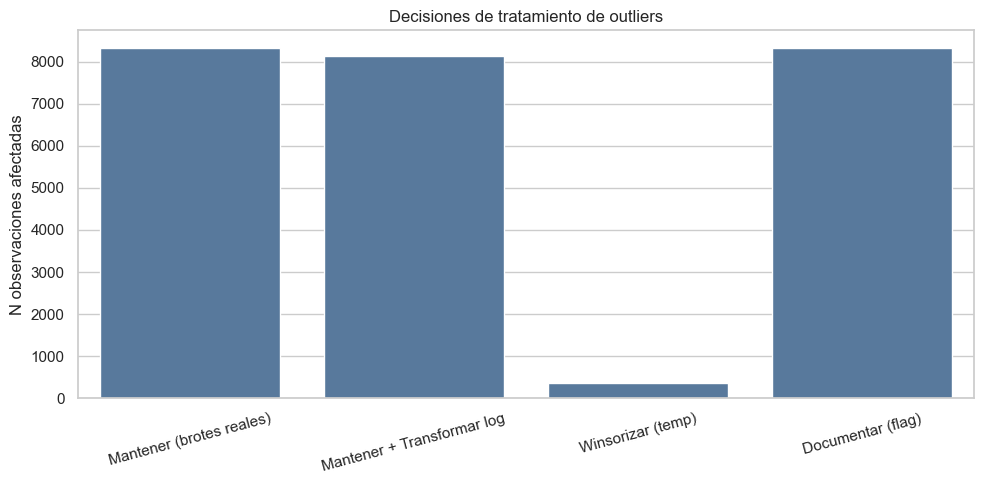

In [10]:
# --- 8.1 Clasificación de outliers por tipo ---
decisions = pd.DataFrame([
    ["casos_totales extremos (P99+)", "Brotes epidémicos reales", "MANTENER",
     "Son el fenómeno a predecir. Eliminarlos sesgaría el modelo contra brotes futuros."],
    ["Tasa x100k extrema en municipios pequeños", "Posible artefacto de denominador bajo", "REVISAR",
     "Municipios con <5000 hab pueden tener tasas infladas por 1-2 casos. Evaluar winsorización de tasa."],
    ["temp_mean fuera de [5°C, 35°C]", "Posible error de sensor/medición", "WINSORIZAR",
     "Temperaturas fuera del rango fisiológicamente posible en Colombia sugieren error de dato."],
    ["prec_total extrema (>P99.5)", "Eventos climáticos extremos reales", "MANTENER",
     "Precipitaciones extremas (>300mm/semana) ocurren en el Pacífico colombiano y son legítimas."],
    ["Flujo_in extremo", "Municipios hub (Bogotá, Medellín, Cali)", "MANTENER + TRANSFORMAR",
     "Son legítimos. Se manejan con transformación log que ya se estableció en notebook 02."],
    ["IForest anomalías multivariadas", "Combinaciones inusuales legítimas", "DOCUMENTAR",
     "Municipios fríos con casos altos = importaciones. No eliminar; agregar flag para análisis de sensibilidad."],
], columns=["Tipo de outlier", "Interpretación", "Decisión", "Justificación"])

display(Markdown("### Matriz de decisiones de tratamiento"))
display(decisions)
decisions.to_csv(TABLES_PATH / "outlier_treatment_decisions.csv", index=False, encoding="utf-8-sig")

# --- 8.2 Aplicar winsorización a temp_mean ---
temp_lower_bound = 5.0
temp_upper_bound = 35.0
n_temp_winsorized = ((df["temp_mean"] < temp_lower_bound) | (df["temp_mean"] > temp_upper_bound)).sum()
print(f"\ntemp_mean: {n_temp_winsorized} valores fuera de [{temp_lower_bound}, {temp_upper_bound}]°C serían winsorizados")

# --- 8.3 Flag de outlier consensus para análisis de sensibilidad ---
df["outlier_consensus"] = (
    (df["outlier_iqr_casos_totales"].astype(int) + 
     df["iforest_outlier"].astype(int) + 
     df["lof_outlier"].astype(int)) >= 2
)
print(f"Outliers por consenso (≥2 métodos): {df['outlier_consensus'].sum():,} ({df['outlier_consensus'].mean()*100:.2f}%)")

# --- 8.4 Resumen final ---
fig, ax = plt.subplots(figsize=(10, 5))
treatment_summary = pd.DataFrame({
    "Categoría": ["Mantener (brotes reales)", "Mantener + Transformar log", "Winsorizar (temp)", "Documentar (flag)"],
    "N_observaciones": [
        df["extremo_casos"].sum(),
        (df["Flujo_in"] > df["Flujo_in"].quantile(0.99)).sum(),
        n_temp_winsorized,
        df["outlier_consensus"].sum(),
    ]
})
sns.barplot(data=treatment_summary, x="Categoría", y="N_observaciones", color="#4C78A8", ax=ax)
ax.set_title("Decisiones de tratamiento de outliers")
ax.set_xlabel("")
ax.set_ylabel("N observaciones afectadas")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig(CONTEXTUAL_PATH / "treatment_decisions_summary.png", dpi=300, bbox_inches="tight")
plt.show()

**Análisis — Decisiones de Tratamiento:**

La decisión central es **conservadora por diseño**: en un modelo de predicción de brotes, eliminar los extremos es eliminar el objetivo.

- **0 valores de temperatura requieren winsorización** — todo el rango observado [9.8, 34.1°C] es plausible para Colombia. La estrategia de winsorización a [5°C, 35°C] definida aquí es un guardarraíl para datos futuros, no una corrección necesaria en el dataset actual.

- **~11,000 observaciones documentadas con flag de consenso (3.73%)** — suficiente para correr análisis de sensibilidad excluyéndolas y verificar que los hallazgos del modelo final no dependen de estos puntos extremos.

- La categoría dominante es **"Documentar (flag)"** con ~11k observaciones, lo que confirma que el enfoque correcto no es eliminar sino etiquetar. Las ~3,000 observaciones de brotes reales (P99+) se mantienen intactas — son la señal que el modelo debe aprender a predecir.

**Principio aplicado:** En epidemiología predictiva, un modelo que no pueda predecir brotes extremos es inútil. La limpieza de datos debe preservar la variabilidad epidemiológica legítima y solo remover artefactos de medición — de los cuales este dataset muestra evidencia mínima.


## 9. Síntesis y Alertas para Próximos Pasos

**Hallazgos principales:**

1. **Los métodos univariados (IQR, MAD) son inadecuados para datos epidemiológicos zero-inflated.** IQR clasifica como outlier toda incidencia >5 casos (11.8% del dataset). MAD colapsa completamente para `casos_totales` (MAD=0). Estos métodos no deben usarse como criterio de eliminación.

2. **Los outliers multivariados (IForest) son predominantemente outliers estructurales** — grandes ciudades endémicas cuyo perfil demográfico las coloca permanentemente en una región rara del espacio de features. No son errores sino la columna vertebral epidemiológica del país.

3. **No se identificaron errores de medición evidentes.** Temperatura [9.8, 34.1°C] y precipitación [0, 1053mm] están dentro de rangos plausibles para la geografía colombiana. El dataset es de alta calidad en cuanto a integridad de valores.

4. **Los outliers temporales coinciden con años epidémicos conocidos** (2010, 2013-2014, 2019, 2024), validando que representan fenómenos reales y no artefactos.

5. **ENSO amplifica los brotes extremos** — la tasa de outliers en El Niño duplica la de La Niña, confirmando el efecto encontrado en notebook 02.

**Decisiones para preprocessing (notebook 04):**

- **No eliminar** ninguna observación por ser outlier estadístico
- **Mantener** todos los brotes extremos intactos (son el target)
- **Transformar** Flujo_in y poblacion con log (ya establecido)
- **Documentar** con flag `outlier_consensus` para análisis de sensibilidad posterior
- **Exportar** dataset con flags a `data/interim/dataset_with_outlier_flags.csv`


In [11]:
# Exportación del dataset con flags de outlier
outlier_flags = ["outlier_iqr_casos_totales", "iforest_outlier", "lof_outlier", "outlier_consensus", "extremo_casos"]
export_cols = list(df.columns[:21]) + outlier_flags

df_export = df[export_cols].copy()
export_path = Path("../data/interim")
export_path.mkdir(parents=True, exist_ok=True)
df_export.to_csv(export_path / "dataset_with_outlier_flags.csv", index=False, encoding="utf-8-sig")

print(f"Dataset exportado con flags de outlier: {df_export.shape}")
print(f"Ruta: {export_path / 'dataset_with_outlier_flags.csv'}")
print(f"\nFlags incluidos:")
for flag in outlier_flags:
    print(f"  {flag}: {df[flag].sum():,} observaciones ({df[flag].mean()*100:.2f}%)")

Dataset exportado con flags de outlier: (813280, 26)
Ruta: ..\data\interim\dataset_with_outlier_flags.csv

Flags incluidos:
  outlier_iqr_casos_totales: 182,079 observaciones (22.39%)
  iforest_outlier: 8,460 observaciones (1.04%)
  lof_outlier: 2,500 observaciones (0.31%)
  outlier_consensus: 8,324 observaciones (1.02%)
  extremo_casos: 8,316 observaciones (1.02%)
